## **Cleaning Data in Python live training**


Welcome to this live, hands-on training where you will learn how to effectively diagnose and treat missing data in Python.

The majority of data science work often revolves around pre-processing data, and making sure it's ready for analysis. In this session, we will be covering how transform our raw data into accurate insights. In this notebook, you will learn:

* Import data into `pandas`, and use simple functions to diagnose problems in our data.
* Visualize missing and out of range data using `missingno` and `seaborn`.
* Apply a range of data cleaning tasks that will ensure the delivery of accurate insights.

## **The Dataset**

The dataset to be used in this webinar is a CSV file named `airbnb.csv`, which contains data on airbnb listings in the state of New York. It contains the following columns:

- `listing_id`: The unique identifier for a listing
- `description`: The description used on the listing
- `host_id`: Unique identifier for a host
- `host_name`: Name of host
- `neighbourhood_full`: Name of boroughs and neighbourhoods
- `coordinates`: Coordinates of listing _(latitude, longitude)_
- `Listing added`: Date of added listing
- `room_type`: Type of room
- `rating`: Rating from 0 to 5.
- `price`: Price per night for listing
- `number_of_reviews`: Amount of reviews received
- `last_review`: Date of last review
- `reviews_per_month`: Number of reviews per month
- `availability_365`: Number of days available per year
- `Number of stays`: Total number of stays thus far


## **Getting started**

In [57]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import datetime as dt
import scipy.stats as ss

In [58]:
# Read in the dataset
airbnb = pd.read_csv('https://raw.githubusercontent.com/kflisikowsky/Descriptive_Statistics/refs/heads/main/data/airbnb.csv', index_col = 'Unnamed: 0')

## **Diagnosing data cleaning problems using simple `pandas` and visualizations**

Some important and common methods needed to get a better understanding of DataFrames and diagnose potential data problems are the following:

- `.head()` prints the header of a DataFrame
- `.dtypes` prints datatypes of all columns in a DataFrame
- `.info()` provides a bird's eye view of column data types and missing values in a DataFrame
- `.describe()` returns a distribution of numeric columns in your DataFrame
- `.isna().sum()` allows us to break down the number of missing values per column in our DataFrame
- `.unique()` finds the number of unique values in a DataFrame column

<br>

- `sns.histplot()` plots the distribution of one column in your DataFrame.

In [59]:
# Print the header of the DataFrame
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


By merely looking at the data, we can already diagnose a range of potential problems down the line such as:

<br>

_Data type problems:_

- **Problem 1**: We can see that the `coordinates` column is probably a string (`str`) - most mapping functions require a latitude input, and longitude input, so it's best to split this column into two and convert the values to `float`.
- **Problem 2**: Similar to `coordinates` - the `price` column also is a string with `$` attached to each price point, we need to convert that to `float` if we want a good understanding of the dataset.
- **Problem 3**: We need to make sure date columns (`last_review` and `listing_added`) are in `datetime` to allow easier manipulation of data data.

<br>

_Missing data problems:_

- **Problem 4**: We can see that there are missing data in some columns, we'll get a better bird's eye view of that down the line.

<br>

_Text/categorical data problems:_


- **Problem 5**: To be able to visualize number of listings by boroughs - we need to separate neighborhoud name from borough name in `neighbourhood_full` column.
- **Problem 6**: Looking at `room_type`, let's replace those values to make them `'Shared Room'`, `'Private Home/Apartment'`, `'Private Room'` and `'Hotel Room'`.

In [60]:
# Print data types of DataFrame
airbnb.dtypes

listing_id              int64
name                      str
host_id                 int64
host_name                 str
neighbourhood_full        str
coordinates               str
room_type                 str
price                     str
number_of_reviews       int64
last_review               str
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added             str
dtype: object

Printing the data types confirms that `coordinates` and `price` need to be converted to `float`, and date columns need to be converted to `datetime` _(**problems 1,2 3)**_

In [61]:
# Print info of DataFrame
airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 10019 entries, 0 to 10018
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          10019 non-null  int64  
 1   name                10014 non-null  str    
 2   host_id             10019 non-null  int64  
 3   host_name           10017 non-null  str    
 4   neighbourhood_full  10019 non-null  str    
 5   coordinates         10019 non-null  str    
 6   room_type           10019 non-null  str    
 7   price               9781 non-null   str    
 8   number_of_reviews   10019 non-null  int64  
 9   last_review         7944 non-null   str    
 10  reviews_per_month   7944 non-null   float64
 11  availability_365    10019 non-null  int64  
 12  rating              7944 non-null   float64
 13  number_of_stays     7944 non-null   float64
 14  5_stars             7944 non-null   float64
 15  listing_added       10019 non-null  str    
dtypes: float64(4), 

Printing the info confirms our hunch about the following:

- There is missing data in the `price`, `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, `5_stars` columns. It also seems that the missingness of `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, `5_stars` are related since they have the same amount of missing data. We will confirm later with `missingno` _(**problem 4**)_.

In [62]:
# Print number of missing values
airbnb.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                  238
number_of_reviews        0
last_review           2075
reviews_per_month     2075
availability_365         0
rating                2075
number_of_stays       2075
5_stars               2075
listing_added            0
dtype: int64

There are a variety of ways of dealing with missing data that is dependent on type of missingness, as well as the business assumptions behind our data - our options could be:

- Dropping missing data (if the data dropped does not impact or skew our data)
- Setting to missing and impute with statistical measures (median, mean, mode ...)
- Imputing with more complex algorithmic/machine learning based approaches
- Impute based on business assumptions of our data

In [63]:
# Print description of DataFrame
airbnb.describe()

,listing_id,host_id,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars
count,1.001900e+04,1.001900e+04,10019.000000,7944.000000,10019.000000,7944.000000,7944.000000,7944.000000
mean,1.927634e+07,6.795923e+07,22.459727,1.353894,112.284260,4.014458,33.991541,0.718599
std,1.095056e+07,7.863106e+07,43.173896,1.615380,131.636043,0.575064,56.089279,0.079978
min,3.831000e+03,2.787000e+03,0.000000,0.010000,0.000000,3.000633,1.200000,0.600026
25%,9.674772e+06,7.910880e+06,1.000000,0.200000,0.000000,3.520443,3.600000,0.655576
50%,2.007030e+07,3.165167e+07,5.000000,0.710000,44.000000,4.027965,10.800000,0.709768
75%,2.933864e+07,1.074344e+08,22.000000,2.000000,226.000000,4.516378,38.400000,0.763978
max,3.648724e+07,2.741034e+08,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339




- **Problem 7:** Looking at the maximum of the `rating` column - we see that it is out of range of `5` which is the maximum rating possible. We need to make sure we fix the range this column.

It's worth noting that `.describe()` does not offer a bird's eye view of all the out of range data we have, for example, what if we have date data in the future? Or given our dataset, `listing_added` dates that are in the future of `last_review` dates?

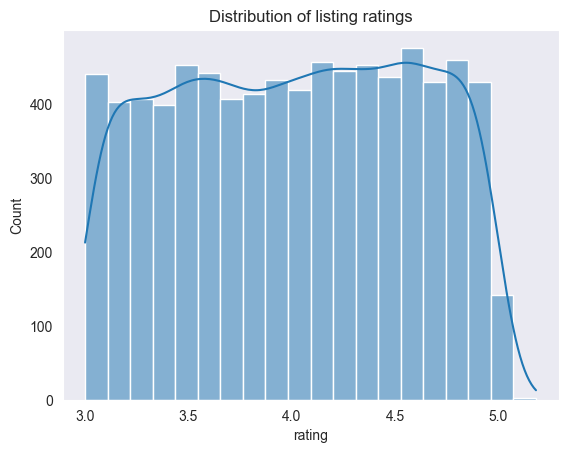

In [64]:
# Visualize the distribution of the rating column
sns.histplot(airbnb['rating'], kde=True, bins = 20)
plt.title('Distribution of listing ratings')
plt.show()

In [65]:
# Find number of unique values in room_type column
airbnb['room_type'].unique()

<StringArray>
[        'Private room',      'Entire home/apt',              'Private',
          'Shared room',         'PRIVATE ROOM',                 'home',
 '   Shared room      ']
Length: 7, dtype: str

- **Problem 8**: There are trailing spaces and capitalization issues with `room_type`, we need to fix this problem.

In [66]:
# How many values of different room_types do we have?
airbnb['room_type'].value_counts()

room_type
Entire home/apt         5120
Private room            4487
Shared room              155
Private                   89
   Shared room            71
home                      66
PRIVATE ROOM              31
Name: count, dtype: int64

In [67]:
airbnb['price'].head(5)

0     45$
1    135$
2    150$
3     86$
4    160$
Name: price, dtype: str

## **Our to do list:**

_Data type problems:_

- **Task 1**: Split `coordinates` into 2 columns and convert them to `float`
- **Task 2**: Remove `$` from `price` and convert it to `float`
- **Task 3**: Convert `listing_added` and `last_review` to `datetime`

<br>

_Text/categorical data problems:_

- **Task 4**: We need to collapse `room_type` into correct categories
- **Task 5**: Divide `neighbourhood_full` into 2 columns and making sure they are clean

<br>

_Data range problems:_

- **Task 6**: Make sure we set the correct maximum for `rating` column out of range values

<br>

_Dealing with missing data:_

- **Task 7**: Understand the type of missingness, and deal with the missing data in most of the remaining columns.

<br>

_Is that all though?_

- We need to investigate if we duplicates in our data
- We need to make sure that data makes sense by applying some sanity checks on our DataFrame

## **Q&A**

## **Cleaning data**

### Data type problems

In [68]:
# Reminder of the DataFrame
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


##### **Task 1:** Replace `coordinates` with `latitude` and `longitude` columns

To perform this task, we will use the following methods:

- `.str.replace("","")` replaces one string in each row of a column with another
- `.str.split("")` takes in a string and lets you split a column into two based on that string
- `.astype()` lets you convert a column from one type to another

In [69]:
airbnb["coordinates"] = airbnb["coordinates"].str.replace("(", "", regex=False).str.replace(")", "", regex=False)

airbnb[["latitude", "longitude"]] = airbnb["coordinates"].str.split(",", expand=True)

airbnb["latitude"] = airbnb["latitude"].astype(float)
airbnb["longitude"] = airbnb["longitude"].astype(float)

columns_id = airbnb.columns.get_loc("coordinates")

airbnb = airbnb.drop(columns="coordinates")

lat = airbnb.pop("latitude")
lon = airbnb.pop("longitude")

airbnb.insert(columns_id, "latitude", lat)
airbnb.insert(columns_id + 1, "longitude", lon)

airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,latitude,longitude,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands",40.63222,-73.93398,Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side",40.78761,-73.96862,Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights",40.70070,-73.99517,Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side",40.79169,-73.97498,Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side",40.71884,-73.98354,Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


##### **Task 2:** Remove `$` from `price` and convert it to `float`

To perform this task, we will be using the following methods:

- `.str.strip()` which removes a specified string from each row in a column
- `.astype()`

In [70]:
# Calculate mean of price without conversion
# airbnb['price'].mean()

In [71]:
# Remove $ from price before conversion to float
airbnb['price'] = airbnb['price'].str.strip("$")
# Print header to make sure change was done
airbnb['price'].head()

0     45
1    135
2    150
3     86
4    160
Name: price, dtype: str

In [72]:
# Convert price to float
airbnb['price'] = airbnb['price'].astype('float')
# Calculate mean of price after conversion
avg = airbnb['price'].mean()
airbnb['price'] = airbnb['price'].fillna(avg)

print(airbnb["price"].isna().sum())
airbnb.head()


0


,listing_id,name,host_id,host_name,neighbourhood_full,latitude,longitude,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands",40.63222,-73.93398,Private room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side",40.78761,-73.96862,Entire home/apt,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights",40.70070,-73.99517,Entire home/apt,150.0,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side",40.79169,-73.97498,Entire home/apt,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side",40.71884,-73.98354,Private room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


##### **Task 3:** Convert `listing_added` and `last_review` columns to `datetime`

To perform this task, we will use the following functions:

- `pd.to_datetime(format = "")`
  - `format` takes in the desired date format `"%Y-%m-%d"`

In [73]:
# Print header of two columns
airbnb[['listing_added', 'last_review']].head()

,listing_added,last_review
0,2018-06-08,2018-12-12
1,2018-12-25,2019-06-30
2,2018-08-15,NaN
3,2017-03-20,2017-09-23
4,2020-10-23,2019-06-12


In [74]:
airbnb["listing_added"] = pd.to_datetime(airbnb["listing_added"], format="%Y-%m-%d")
airbnb["last_review"] = pd.to_datetime(airbnb["last_review"], format="%Y-%m-%d")

airbnb[['listing_added', 'last_review']].head()

,listing_added,last_review
0,2018-06-08,2018-12-12
1,2018-12-25,2019-06-30
2,2018-08-15,NaT
3,2017-03-20,2017-09-23
4,2020-10-23,2019-06-12


### Text and categorical data problems

##### **Task 4:** We need to collapse `room_type` into correct categories

To perform this task, we will be using the following methods:

- `.str.lower()` to lowercase all rows in a string column
- `.str.strip()` to remove all white spaces of each row in a string column
- `.replace()` to replace values in a column with another

In [75]:
# Print unique values of `room_type`
airbnb['room_type'].unique()

<StringArray>
[        'Private room',      'Entire home/apt',              'Private',
          'Shared room',         'PRIVATE ROOM',                 'home',
 '   Shared room      ']
Length: 7, dtype: str

In [76]:
# Deal with capitalized values
airbnb['room_type'] = airbnb['room_type'].str.lower()
airbnb['room_type'].unique()

<StringArray>
[        'private room',      'entire home/apt',              'private',
          'shared room',                 'home', '   shared room      ']
Length: 6, dtype: str

In [77]:
# Deal with trailing spaces
airbnb['room_type'] = airbnb['room_type'].str.strip()
airbnb['room_type'].unique()

<StringArray>
['private room', 'entire home/apt', 'private', 'shared room', 'home']
Length: 5, dtype: str

In [78]:
# Replace values to 'Shared room', 'Entire place', 'Private room' and 'Hotel room' (if applicable).
mappings = {'private room': 'Private Room',
            'private': 'Private Room',
            'entire home/apt': 'Entire place',
            'shared room': 'Shared room',
            'home': 'Entire place'}

# Replace values and collapse data
airbnb['room_type'] = airbnb['room_type'].replace(mappings)
airbnb['room_type'].unique()

airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,latitude,longitude,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands",40.63222,-73.93398,Private Room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side",40.78761,-73.96862,Entire place,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights",40.70070,-73.99517,Entire place,150.0,0,NaT,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side",40.79169,-73.97498,Entire place,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side",40.71884,-73.98354,Private Room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


##### **Task 5:** Divide `neighbourhood_full` into 2 columns and making sure they are clean

In [79]:
# Print header of column
# airbnb['neighbourhood_full'].head()

In [80]:
airbnb[["borough", "neighbourhood"]] = airbnb["neighbourhood_full"].str.split(", ", expand=True)

neigh_id = airbnb.columns.get_loc("neighbourhood_full")

airbnb = airbnb.drop(columns="neighbourhood_full")

neigh = airbnb.pop("neighbourhood")
borough = airbnb.pop("borough")

airbnb.insert(neigh_id, "borough", borough)
airbnb.insert(neigh_id + 1, "neighbourhood", neigh)

airbnb.head()


,listing_id,name,host_id,host_name,borough,neighbourhood,latitude,longitude,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Brooklyn,Flatlands,40.63222,-73.93398,Private Room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Manhattan,Upper West Side,40.78761,-73.96862,Entire place,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Brooklyn,Brooklyn Heights,40.70070,-73.99517,Entire place,150.0,0,NaT,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,Manhattan,Upper West Side,40.79169,-73.97498,Entire place,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,Manhattan,Lower East Side,40.71884,-73.98354,Private Room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


##### **Task 6:** Make sure we set the correct maximum for `rating` column out of range values

In [81]:
airbnb.loc[airbnb["rating"] > 5, "rating"] = 5.0


## **Q&A**

### Dealing with missing data

The `missingno` (imported as `msno`) package is great for visualizing missing data - we will be using:

- `msno.matrix()` visualizes a missingness matrix
- `msno.bar()` visualizes a missngness barplot
- `plt.show()` to show the plot

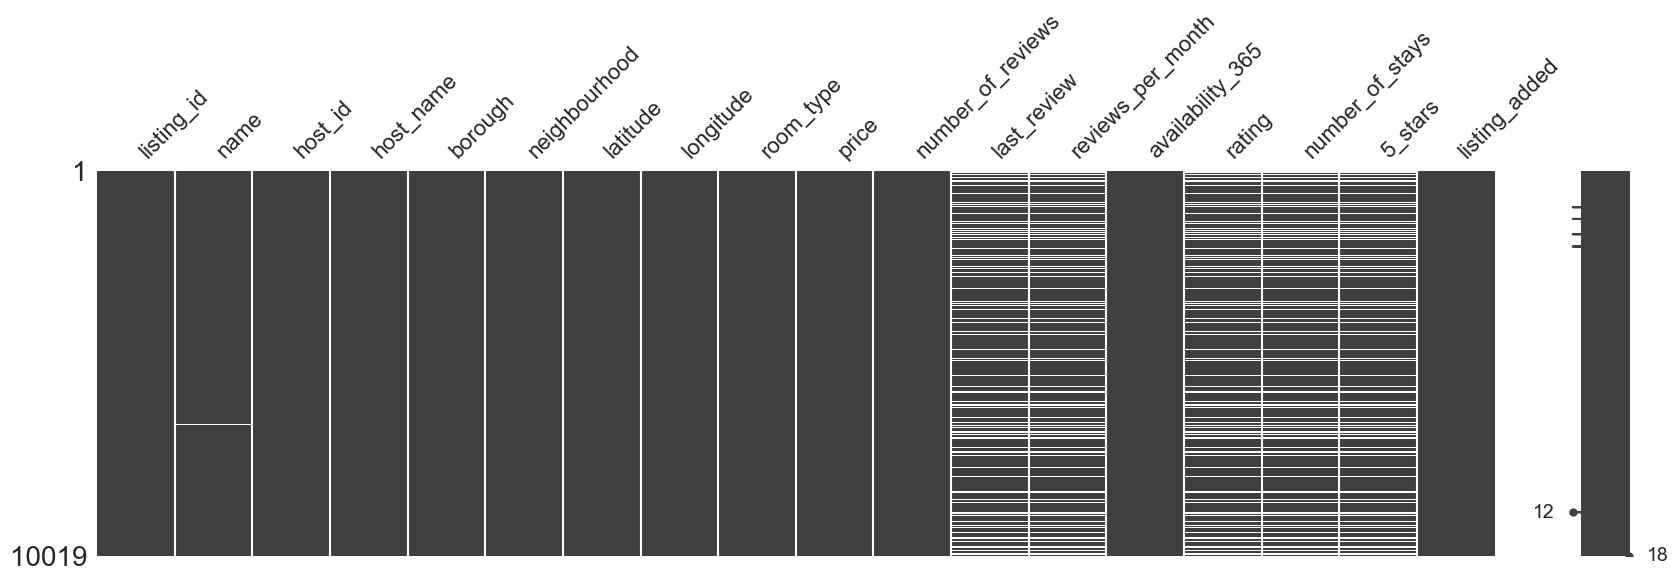

In [82]:
# Visualize the missingness
msno.matrix(airbnb, figsize=(20, 5))
plt.show()

Looking at the missingness matrix, we can see that missing values are almost identical between `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, and `5_stars`. Let's confirm this further by sorting on `rating`.

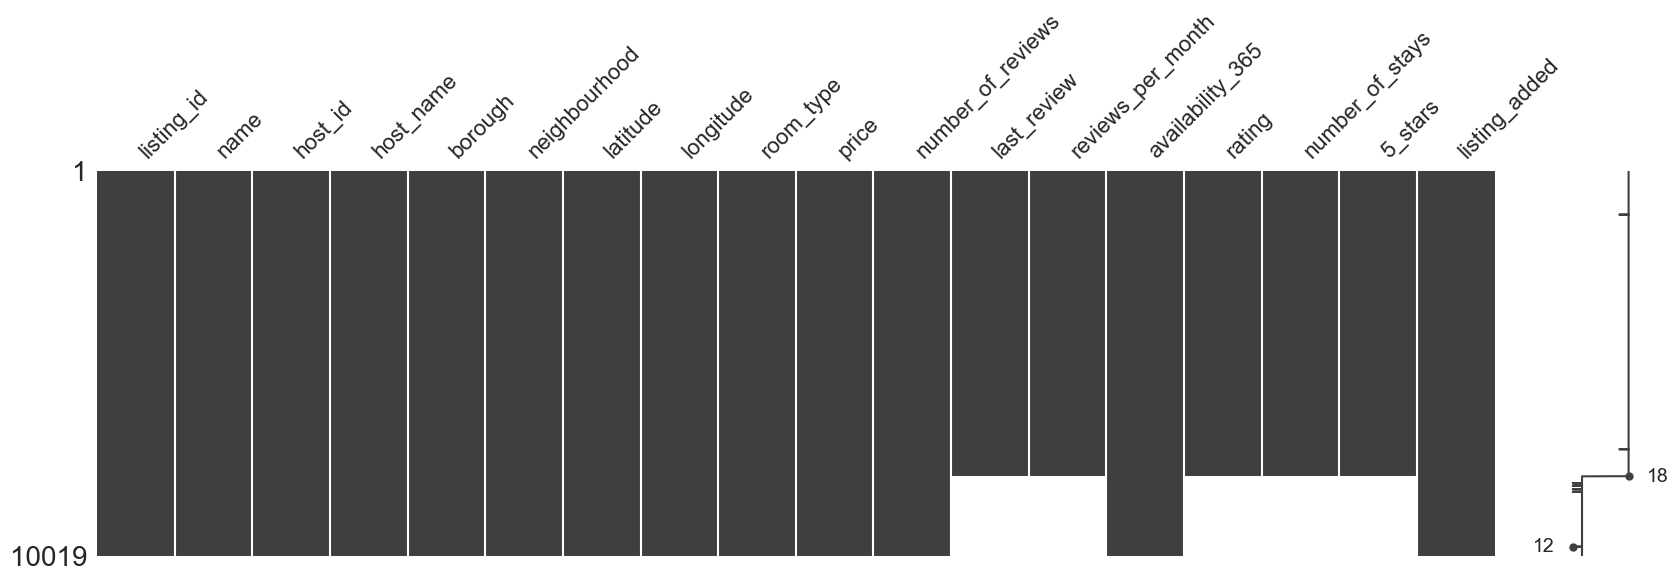

In [83]:
# Visualize the missingness on sorted values
msno.matrix(airbnb.sort_values(by = 'rating'), figsize=(20, 5))
plt.show()

<Axes: >

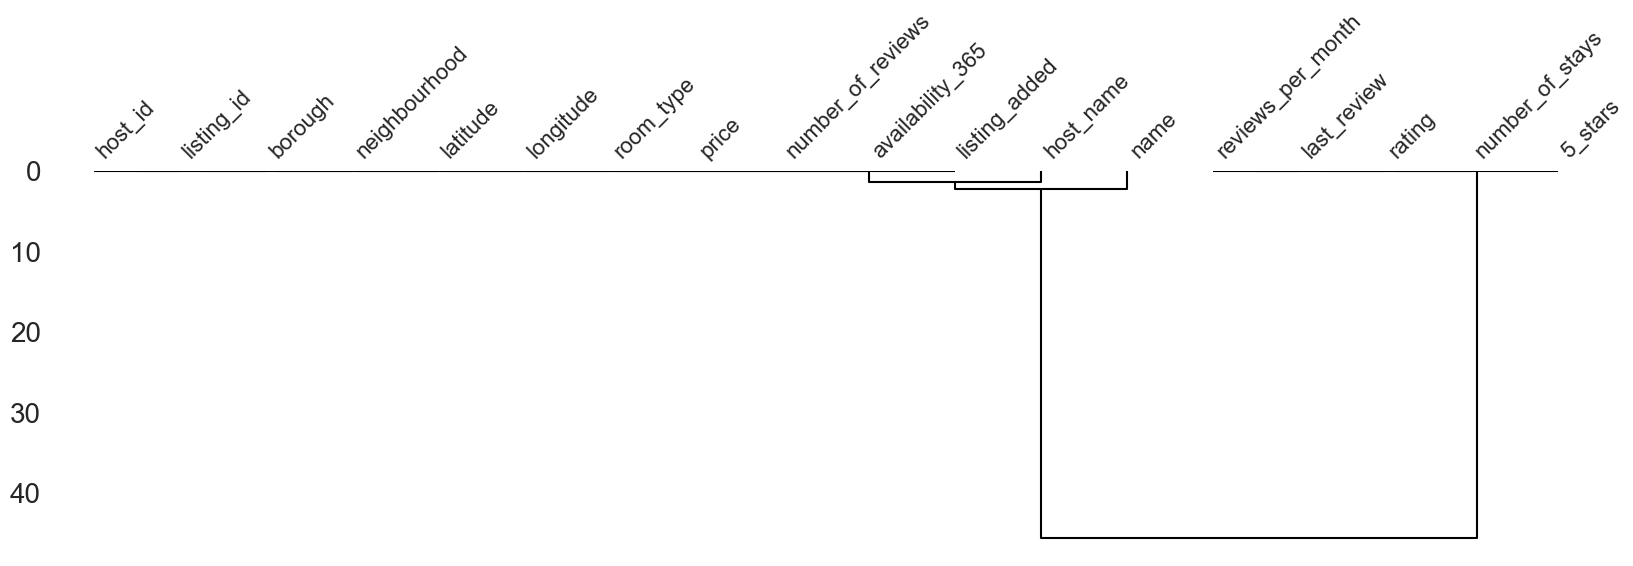

In [84]:
# Missingness barplot
msno.dendrogram(airbnb, figsize=(20,5))


**Treating the** `rating`, `number_of_stays`, `5_stars`, `reviews_per_month` **columns**

In [85]:
# Understand DataFrame with missing values in rating, number_of_stays, 5_stars, reviews_per_month
airbnb[airbnb['rating'].isna()].describe()

,listing_id,host_id,latitude,longitude,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
count,2.075000e+03,2.075000e+03,2075.000000,2075.000000,2075.000000,2075.0,0,0.0,2075.000000,0.0,0.0,0.0,2075
mean,2.274238e+07,8.022455e+07,40.732074,-73.956771,190.633032,0.0,NaT,NaN,104.531566,NaN,NaN,NaN,2018-06-08 17:01:31.951807
min,6.358800e+04,1.475100e+04,40.527000,-74.209410,0.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-02-03 00:00:00
25%,1.232923e+07,1.224305e+07,40.697845,-73.985185,70.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-04-05 00:00:00
50%,2.345182e+07,4.040116e+07,40.727790,-73.960940,120.000000,0.0,NaT,NaN,7.000000,NaN,NaN,NaN,2018-06-05 00:00:00
75%,3.400364e+07,1.333498e+08,40.763480,-73.939540,200.000000,0.0,NaT,NaN,211.000000,NaN,NaN,NaN,2018-08-13 00:00:00
max,3.648724e+07,2.741034e+08,40.911690,-73.727310,5250.000000,0.0,NaT,NaN,365.000000,NaN,NaN,NaN,2018-10-17 00:00:00
std,1.123730e+07,8.663163e+07,0.051168,0.041065,312.642005,0.0,NaN,NaN,138.266525,NaN,NaN,NaN,NaN


In [86]:
# Understand DataFrame with missing values in rating, number_of_stays, 5_stars, reviews_per_month
airbnb[~airbnb['rating'].isna()].describe()

,listing_id,host_id,latitude,longitude,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
count,7.944000e+03,7.944000e+03,7944.000000,7944.000000,7944.000000,7944.000000,7944,7944.000000,7944.000000,7944.000000,7944.000000,7944.000000,7944
mean,1.837100e+07,6.475548e+07,40.728325,-73.950642,140.528056,28.326284,2018-10-07 03:30:05.438066,1.353894,114.309290,4.014422,33.991541,0.718599,2018-04-03 15:56:11.601208
min,3.831000e+03,2.787000e+03,40.508680,-74.239860,0.000000,1.000000,2011-03-28 00:00:00,0.010000,0.000000,3.000633,1.200000,0.600026,2010-09-22 00:00:00
25%,8.970241e+06,7.137797e+06,40.688567,-73.982152,69.000000,3.000000,2018-07-16 00:00:00,0.200000,0.000000,3.520443,3.600000,0.655576,2018-01-10 00:00:00
50%,1.928118e+07,2.949374e+07,40.721785,-73.954415,109.000000,9.000000,2019-05-19 00:00:00,0.710000,54.000000,4.027965,10.800000,0.709768,2018-11-13 00:00:00
75%,2.789420e+07,1.016715e+08,40.763360,-73.934930,169.000000,32.000000,2019-06-23 00:00:00,2.000000,229.000000,4.516378,38.400000,0.763978,2018-12-18 00:00:00
max,3.641363e+07,2.733615e+08,40.913060,-73.719280,8000.000000,510.000000,2019-07-08 00:00:00,16.220000,365.000000,5.000000,612.000000,0.950339,2020-10-23 00:00:00
std,1.069161e+07,7.608428e+07,0.055482,0.047013,161.696882,46.741066,NaN,1.615380,129.781153,0.574998,56.089279,0.079978,NaN


Looking at the missing data in the DataFrame - we can see that `number_of_reviews` across all missing rows is 0. We can infer that these listings have never been visited - hence could be inferred they're inactive/have never been visited.

We can impute them as following:

- Set `NaN` for `reviews_per_month`, `number_of_stays`, `5_stars` to 0.
- Since a `rating` did not happen, let's keep the column as is - but create a new column named `rated` that takes in `1` if yes, `0` if no.
- We will also leave `last_review` as is.


In [87]:
# Impute missing data
airbnb = airbnb.fillna({'reviews_per_month':0,
                        'number_of_stays':0,
                        '5_stars':0})

# Create is_rated column
is_rated = np.where(airbnb['rating'].isna() == True, 0, 1)
airbnb['is_rated'] = is_rated

**Treating the** `price` **column**

In [88]:
# Investigate DataFrame with missing values in price
airbnb[airbnb['price'].isna()].describe()

,listing_id,host_id,latitude,longitude,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,is_rated
count,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
# Investigate DataFrame with missing values in price
airbnb[~airbnb['price'].isna()].describe()

,listing_id,host_id,latitude,longitude,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,is_rated
count,1.001900e+04,1.001900e+04,10019.000000,10019.000000,10019.000000,10019.000000,7944,10019.000000,10019.000000,7944.000000,10019.000000,10019.000000,10019,10019.000000
mean,1.927634e+07,6.795923e+07,40.729102,-73.951911,150.905122,22.459727,2018-10-07 03:30:05.438066,1.073493,112.284260,4.014422,26.951672,0.569772,2018-04-17 08:13:07.623515,0.792894
min,3.831000e+03,2.787000e+03,40.508680,-74.239860,0.000000,0.000000,2011-03-28 00:00:00,0.000000,0.000000,3.000633,0.000000,0.000000,2010-09-22 00:00:00,0.000000
25%,9.674772e+06,7.910880e+06,40.689880,-73.982845,70.000000,1.000000,2018-07-16 00:00:00,0.040000,0.000000,3.520443,1.200000,0.611660,2018-03-08 00:00:00,1.000000
50%,2.007030e+07,3.165167e+07,40.723010,-73.955430,110.000000,5.000000,2019-05-19 00:00:00,0.370000,44.000000,4.027965,6.000000,0.681930,2018-09-09 00:00:00,1.000000
75%,2.933864e+07,1.074344e+08,40.763390,-73.936065,175.000000,22.000000,2019-06-23 00:00:00,1.550000,226.000000,4.516378,26.400000,0.750088,2018-12-14 00:00:00,1.000000
max,3.648724e+07,2.741034e+08,40.913060,-73.719280,8000.000000,510.000000,2019-07-08 00:00:00,16.220000,365.000000,5.000000,612.000000,0.950339,2020-10-23 00:00:00,1.000000
std,1.095056e+07,7.863106e+07,0.054636,0.045910,203.417189,43.173896,NaN,1.539481,131.636043,0.574998,51.808675,0.299795,NaN,0.405253


From a common sense perspective, the most predictive factor for a room's price is the `room_type` column, so let's visualize how price varies by room type with `sns.boxplot()` which displays the following information:


<p align="center">
<img src="https://github.com/adelnehme/cleaning-data-in-python-live-training/blob/master/boxplot.png?raw=true" alt = "DataCamp icon" width="80%">
</p>




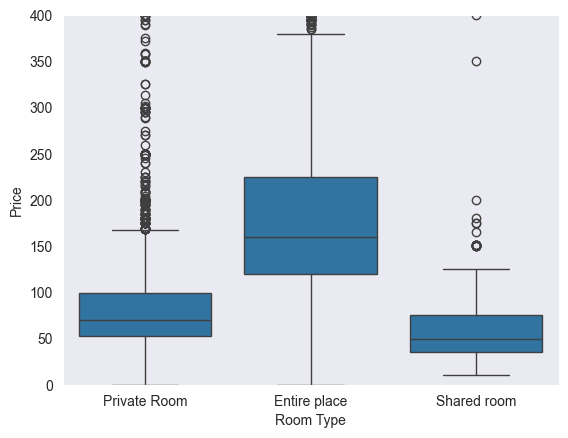

In [90]:
# Visualize relationship between price and room_type
sns.boxplot(x = 'room_type', y = 'price', data = airbnb)
plt.ylim(0, 400)
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

In [91]:
# Get median price per room_type
airbnb.groupby('room_type')['price'].median()

room_type
Entire place    160.0
Private Room     70.0
Shared room      50.0
Name: price, dtype: float64

In [92]:
# Impute price based on conditions
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Entire place'), 'price'] = 163.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Private Room'), 'price'] = 70.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Shared room'), 'price'] = 50.0

In [93]:
# Confirm price has been imputed
airbnb.isna().sum()

listing_id              0
name                    5
host_id                 0
host_name               2
borough                 0
neighbourhood           0
latitude                0
longitude               0
room_type               0
price                   0
number_of_reviews       0
last_review          2075
reviews_per_month       0
availability_365        0
rating               2075
number_of_stays         0
5_stars                 0
listing_added           0
is_rated                0
dtype: int64

### What's still to be done?

Albeit we've done a significant amount of data cleaning tasks, there are still a couple of problems we have yet to diagnose. When cleaning data, we need to consider:

- Values that do not make any sense *(for example: are there values of `last_review` that older than `listing_added`? Are there listings in the future?*)
- Presence of duplicates values - and how to deal with them?

##### **Task 8:** Do we have consistent date data?

In [94]:
# Doing some sanity checks on date data
today = dt.date.today()

In [95]:
# Are there reviews in the future?
airbnb[airbnb['last_review'].dt.date > today]

,listing_id,name,host_id,host_name,borough,neighbourhood,latitude,longitude,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,is_rated


In [96]:
# Are there listings in the future?
airbnb[airbnb['listing_added'].dt.date > today]

,listing_id,name,host_id,host_name,borough,neighbourhood,latitude,longitude,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,is_rated


In [97]:
# Drop these rows since they are only 4 rows
airbnb = airbnb[~(airbnb['listing_added'].dt.date > today)]

In [98]:
# Are there any listings with listing_added > last_review
inconsistent_dates = airbnb[airbnb['listing_added'].dt.date > airbnb['last_review'].dt.date]
inconsistent_dates

,listing_id,name,host_id,host_name,borough,neighbourhood,latitude,longitude,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,is_rated
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,Manhattan,Lower East Side,40.71884,-73.98354,Private Room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,1
50,20783900,Marvelous Manhattan Marble Hill Private Suites,148960265,Randy,Manhattan,Marble Hill,40.87618,-73.91266,Private Room,93.0,7,2018-10-06,0.32,0,4.868036,8.4,0.609263,2020-02-17,1
60,1908852,Oversized Studio By Columbus Circle,684629,Alana,Manhattan,Upper West Side,40.77060,-73.98919,Entire place,189.0,7,2016-05-06,0.13,0,4.841204,8.4,0.725995,2017-09-17,1
124,28659894,Private bedroom in prime Bushwick! Near Trains!!!,216235179,Nina,Brooklyn,Bushwick,40.69988,-73.92072,Private Room,55.0,4,2019-04-12,0.58,358,4.916252,4.8,0.703117,2020-08-23,1
511,33619855,Modern & Spacious in trendy Crown Heights,253354074,Yehudis,Brooklyn,Crown Heights,40.66387,-73.93840,Entire place,150.0,6,2019-05-27,2.50,148,3.462432,7.2,0.610929,2020-10-07,1
521,25317793,Awesome Cozy Room in The Heart of Sunnyside!,136406167,Kara,Queens,Sunnyside,40.74090,-73.92696,Private Room,65.0,22,2019-06-11,1.63,131,4.442485,26.4,0.722388,2020-10-22,1


In [99]:
# Drop these rows since they are only 2 rows
airbnb.drop(inconsistent_dates.index, inplace = True)

##### **Task 9:** Let's deal with duplicate data


There are two notable types of duplicate data:

- Identical duplicate data across all columns
- Identical duplicate data cross most or some columns

To diagnose, and deal with duplicate data, we will be using the following methods and functions:

- `.duplicated(subset = , keep = )`
  - `subset` lets us pick one or more columns with duplicate values.
  - `keep` returns lets us return all instances of duplicate values.
- `.drop_duplicates(subset = , keep = )`
  

In [100]:
# Print the header of the DataFrame again
airbnb.head()

,listing_id,name,host_id,host_name,borough,neighbourhood,latitude,longitude,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,is_rated
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Brooklyn,Flatlands,40.63222,-73.93398,Private Room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,1
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Manhattan,Upper West Side,40.78761,-73.96862,Entire place,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,1
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Brooklyn,Brooklyn Heights,40.70070,-73.99517,Entire place,150.0,0,NaT,0.00,65,NaN,0.0,0.000000,2018-08-15,0
3,6425850,"Spacious, charming studio",32715865,Yelena,Manhattan,Upper West Side,40.79169,-73.97498,Entire place,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,1
5,271954,Beautiful brownstone apartment,1423798,Aj,Manhattan,Greenwich Village,40.73388,-73.99452,Entire place,150.0,203,2019-06-20,2.22,300,4.478396,243.6,0.743500,2018-12-15,1


In [101]:
# Find duplicates

print(airbnb.duplicated().sum())


13


In [102]:
# Remove identical duplicates
airbnb = airbnb.drop_duplicates()

In [103]:
# Find non-identical duplicates
duplicates = airbnb[airbnb.duplicated(subset="listing_id", keep=False)]


In [104]:
# Show all duplicates
print(duplicates)

      listing_id                                               name  \
77       7319856                 450ft Square Studio in Gramercy NY   
555      9078222                Prospect Park 3 bdrm, Sleeps 8 (#2)   
1481    15027024  Newly renovated 1bd on lively & historic St Marks   
2255     7319856                 450ft Square Studio in Gramercy NY   
2871     4244242  Best Bedroom in Bedstuy/Bushwick. Ensuite bath...   
3430    15027024  Newly renovated 1bd on lively & historic St Marks   
4187     4244242  Best Bedroom in Bedstuy/Bushwick. Ensuite bath...   
5761     2044392                The heart of Williamsburg 2 bedroom   
7155    35801208                 Comfy 2 bedroom Close To Manhattan   
7316    31470004  Private bedroom/Bathroom in a 2 bedroom apartment   
7933     9078222                Prospect Park 3 bdrm, Sleeps 8 (#2)   
8699     2044392                The heart of Williamsburg 2 bedroom   
9265    35801208                 Comfy 2 bedroom Close To Manhattan   
9322  

To treat identical duplicates across some columns, we will chain the `.groupby()` and `.agg()` methods where we group by the column used to find duplicates (`listing_id`) and aggregate across statistical measures for `price`, `rating` and `list_added`. The `.agg()` method takes in a dictionary with each column's aggregation method - we will use the following aggregations:

- `mean` for `price` and `rating` columns
- `max` for `listing_added` column
- `first` for all remaining column

*A note on dictionary comprehensions:*

Dictionaries are useful data structures in Python with the following format
`my_dictionary = {key: value}` where a `key` is mapped to a `value` and whose `value` can be returned with `my_dictionary[key]` - dictionary comprehensions allow us to programmatically create dicitonaries using the structure:

```
{x: x*2 for x in [1,2,3,4,5]}
{1:2, 2:4, 3:6, 4:8, 5:10}
```

In [105]:
# first for every column in df
agg_instruction = {col: 'first' for col in airbnb.columns} 

# changing only these columns, that should be aggregated differently
agg_instruction["price"] = "mean"
agg_instruction["rating"] = "mean"
agg_instruction["listing_added"] = "max" 

# deleting the column by which elements are grouped
del agg_instruction["listing_id"]

airbnb = airbnb.groupby("listing_id").agg(agg_instruction).reset_index()

print(airbnb.duplicated(subset="listing_id").sum())

0


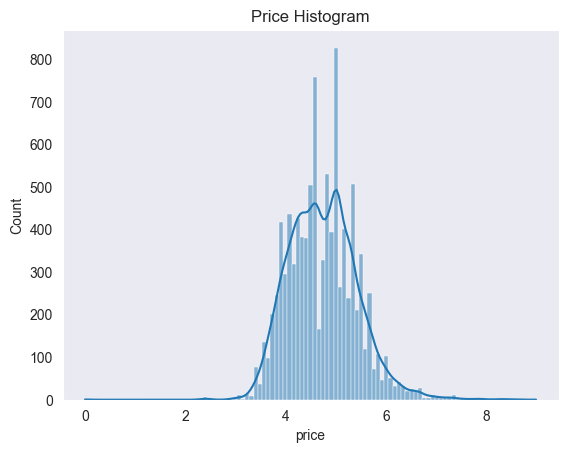

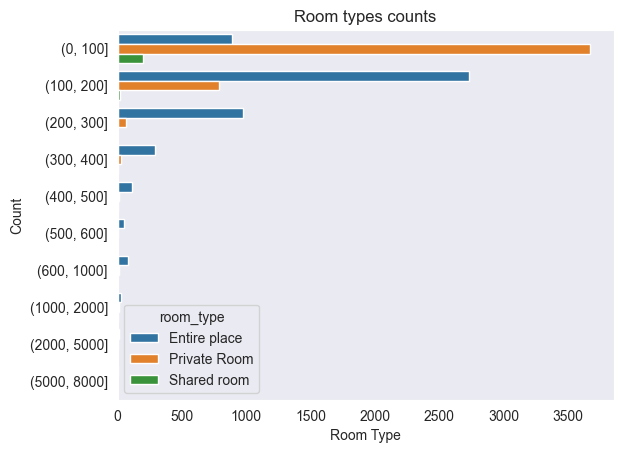

In [106]:
airbnb["name"] = airbnb["name"].fillna("Unknown")
airbnb["host_name"] = airbnb["host_name"].fillna("Unknown")
                                                 
#airbnb.info()

#airbnb.isna().sum()

#airbnb.head()

log_price = np.log1p(airbnb['price'])

sns.set_style('dark')

sns.histplot(log_price, kde=True)
plt.title('Price Histogram')
plt.show()

airbnb['price_cut']=pd.cut(airbnb['price'],
                           [0, 100, 200, 300, 400, 500, 600, 1000, 2000, 5000, 8000])
#sns.countplot(data=airbnb, x='price_cut')

sns.countplot(data=airbnb, y='price_cut', hue='room_type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.title("Room types counts")
plt.show()



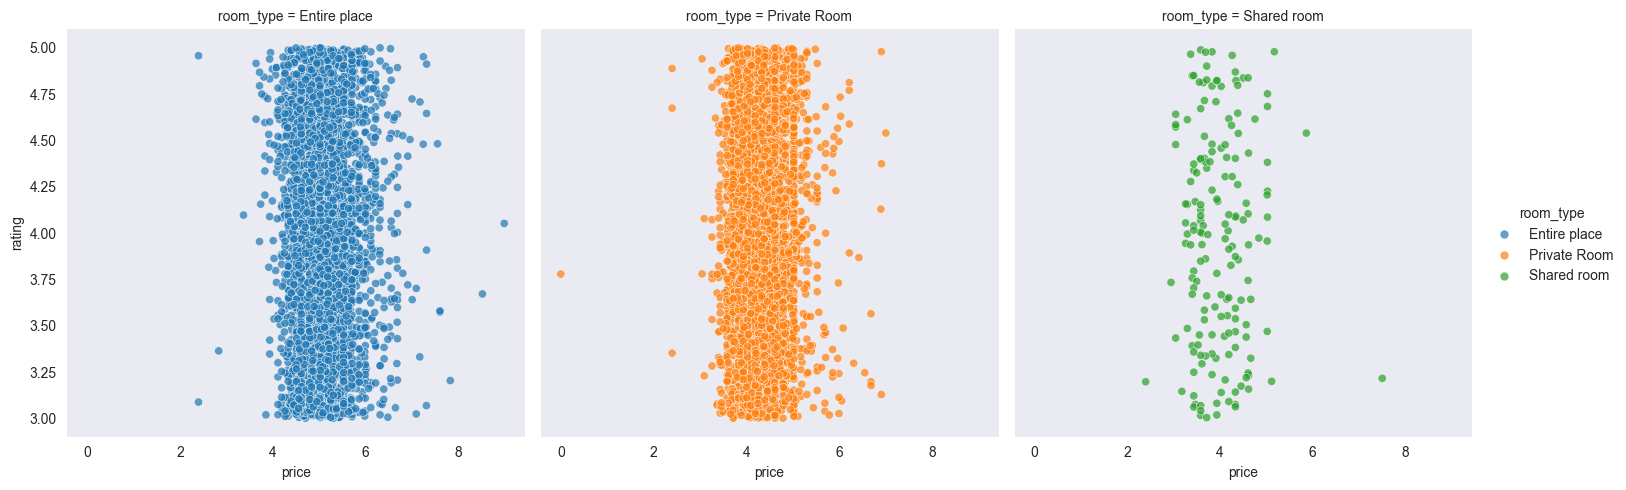

In [107]:
# wykres z rating i price, scatter
sns.relplot(data=airbnb, kind='scatter', x=log_price, y='rating', col='room_type', hue='room_type', alpha=0.7)
plt.show()

In [121]:
airbnb.dropna(inplace=True)
log_price = np.log1p(airbnb['price'])   
ss.pearsonr(log_price, airbnb['rating'])

PearsonRResult(statistic=np.float64(0.0006408894369506826), pvalue=np.float64(0.9545211669705785))

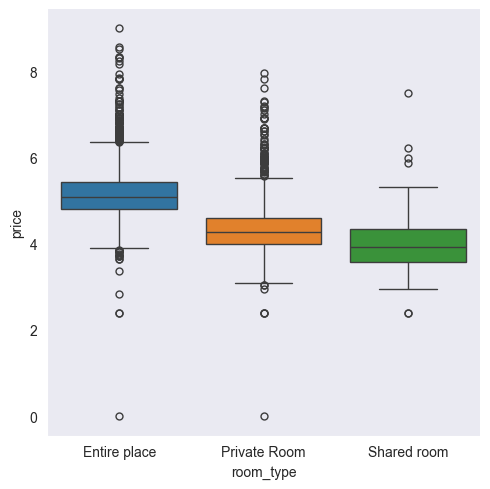

In [128]:
sns.catplot(data=airbnb, kind='box', x='room_type', y=log_price, hue='room_type')
plt.show()

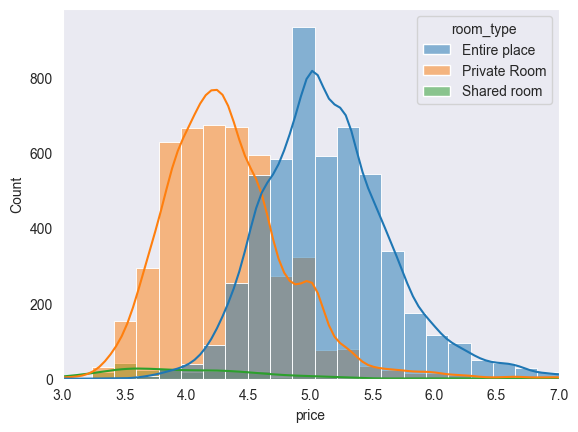

In [139]:
sns.histplot(data=airbnb, x=log_price, hue='room_type', kde=True, alpha=0.5, bins=50)
plt.xlim(3, 7)
plt.show()

In [141]:
airbnb['price'].groupby(airbnb['room_type']).describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire place,5172.0,208.666572,249.272201,0.0,120.0,160.0,225.0,8000.0
Private Room,4595.0,89.307088,102.043095,0.0,53.0,70.0,99.0,2850.0
Shared room,226.0,72.904141,127.992142,10.0,35.0,50.0,75.0,1800.0


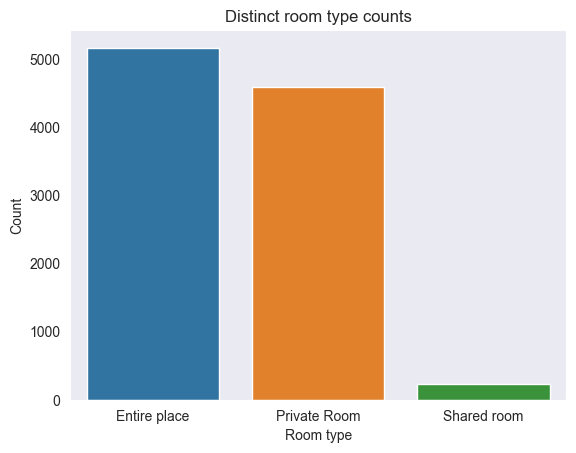

In [145]:
sns.countplot(data=airbnb, x='room_type', hue='room_type')
plt.title('Distinct room type counts')
plt.xlabel('Room type')
plt.ylabel('Count')
plt.show()

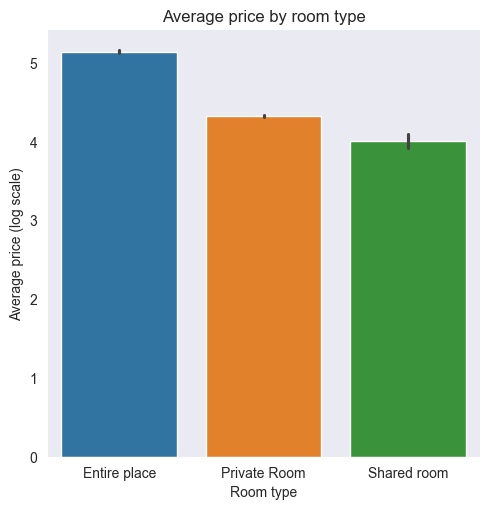

In [151]:
sns.catplot(data=airbnb, kind='bar', x='room_type', y=log_price, hue='room_type')
plt.title('Average price by room type')
plt.xlabel('Room type')
plt.ylabel('Average price (log scale)')
plt.show()

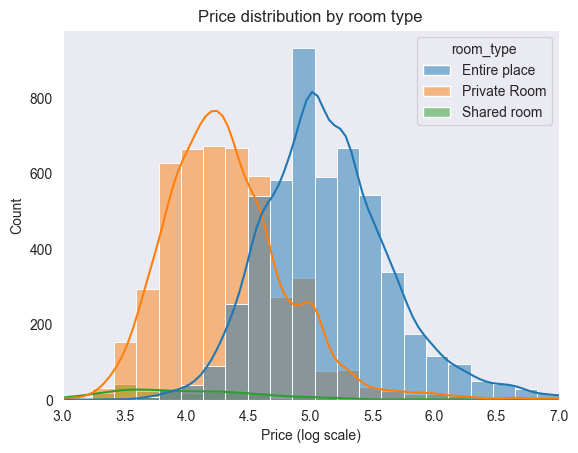

In [153]:
sns.histplot(data=airbnb, x=log_price, hue='room_type', kde=True, alpha=0.5, bins=50)
plt.xlim(3, 7)
plt.title('Price distribution by room type')
plt.xlabel('Price (log scale)')
plt.ylabel('Count')
plt.show()

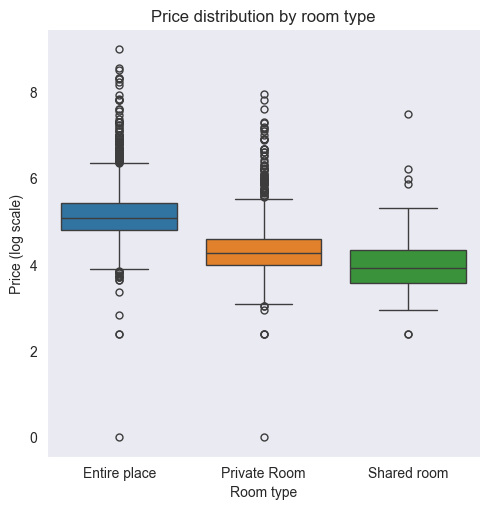

In [154]:
sns.catplot(data=airbnb, kind='box', x='room_type', y=log_price, hue='room_type')
plt.title('Price distribution by room type')
plt.xlabel('Room type')
plt.ylabel('Price (log scale)')
plt.show()

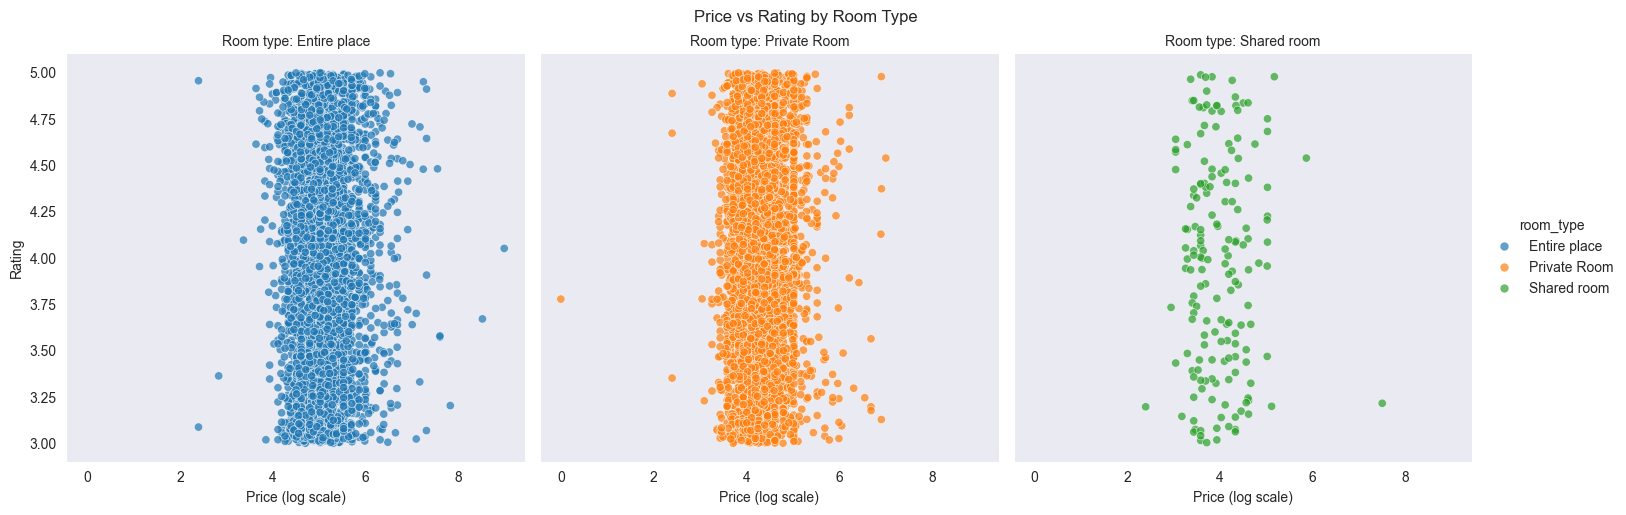

In [157]:
plots = sns.relplot(data=airbnb, kind='scatter', x=log_price, y='rating', col='room_type', hue='room_type', alpha=0.7)
plots.set_axis_labels("Price (log scale)", "Rating")
plots.set_titles("Room type: {col_name}")
plots.fig.suptitle("Price vs Rating by Room Type", y=1.02)
plt.show()

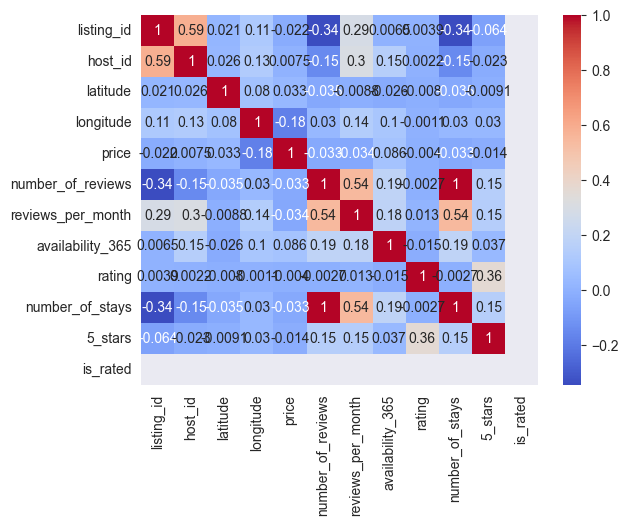

In [120]:
corr = airbnb.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()